In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv("marketing_campaign.csv", sep="\t")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [4]:
df.drop(['ID','Dt_Customer'], axis=1, inplace=True)

In [5]:
df['Age'] = 2026 - df['Year_Birth']

df.drop('Year_Birth', axis=1, inplace=True)

In [7]:
df = pd.get_dummies(
      df,
          columns=['Education','Marital_Status'],
              drop_first=True
              )

In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

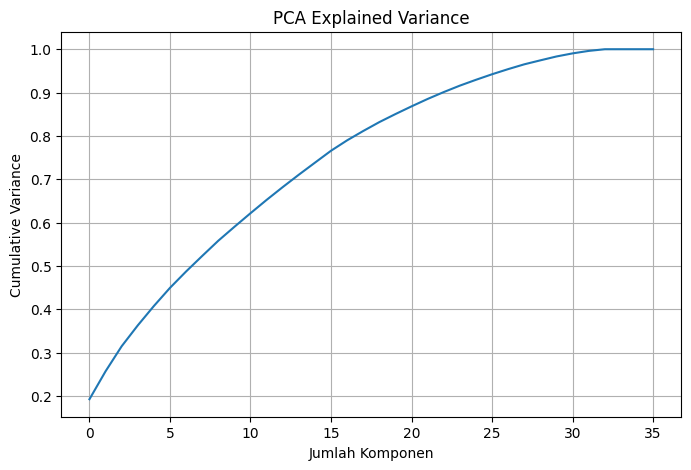

In [10]:
pca = PCA()

pca.fit(X_scaled)

plt.figure(figsize=(8,5))
plt.plot(
    np.cumsum(pca.explained_variance_ratio_)
    )
plt.xlabel("Jumlah Komponen")
plt.ylabel("Cumulative Variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()

In [11]:
pca = PCA(n_components=0.90)

X_pca = pca.fit_transform(X_scaled)

print("Jumlah Komponen PCA :", pca.n_components_)

Jumlah Komponen PCA : 23


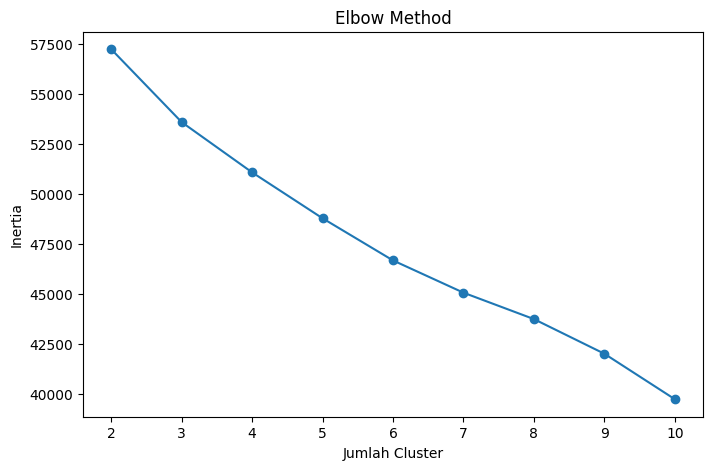

In [13]:
inertia = []

for k in range(2,11):
    km = KMeans(
            n_clusters=k,
                    random_state=42,
                            n_init=10
                                )
    km.fit(X_pca)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker='o')
plt.xlabel("Jumlah Cluster")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [15]:
for k in range(2,11):
    km = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
            )
    labels = km.fit_predict(X_pca)
    score = silhouette_score(
            X_pca,
            labels
            )
    print(f"K={k} --> {score:.4f}")

K=2 --> 0.1962
K=3 --> 0.1337
K=4 --> 0.1335
K=5 --> 0.1538
K=6 --> 0.1387
K=7 --> 0.0935
K=8 --> 0.1087
K=9 --> 0.1135
K=10 --> 0.1084


In [17]:
kmeans = KMeans(
      n_clusters=2,
          random_state=42,
              n_init=10
              )

df['Cluster'] = kmeans.fit_predict(X_pca)

df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,Cluster
0,58138.0,0,0,58,635,88,546,172,88,88,...,False,False,False,False,False,True,False,False,False,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,False,False,False,False,False,True,False,False,False,1
2,71613.0,0,0,26,426,49,127,111,21,42,...,False,False,False,False,False,False,True,False,False,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,False,False,False,False,False,False,True,False,False,1
4,58293.0,1,0,94,173,43,118,46,27,15,...,False,True,False,False,True,False,False,False,False,1


In [19]:
score = silhouette_score(
    X_pca,
    df['Cluster']
)

print("Silhouette Score =", score)

Silhouette Score = 0.19616879786626543


In [20]:
pca2 = PCA(n_components=2)

X_vis = pca2.fit_transform(X_scaled)

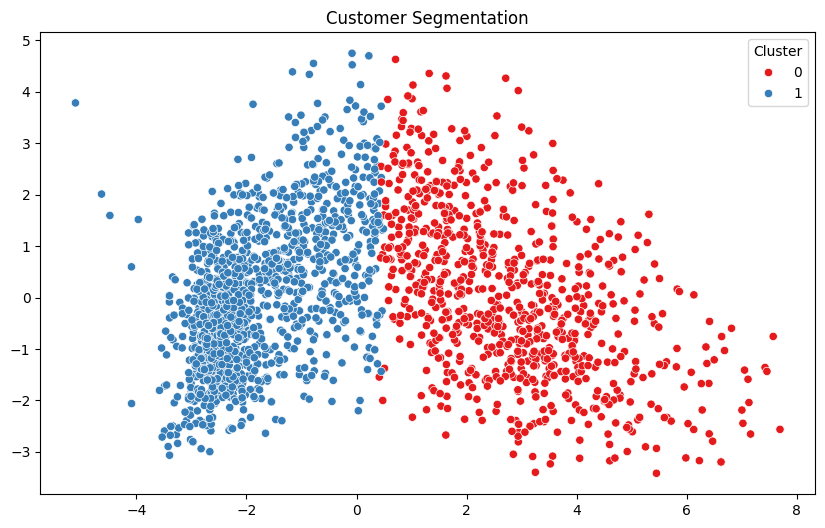

In [22]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=X_vis[:,0],
    y=X_vis[:,1],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("Customer Segmentation")
plt.show()

In [23]:
segment = df.groupby('Cluster').mean()

segment.T

Cluster,0,1
Income,72151.780045,39304.267305
Kidhome,0.065760,0.689985
Teenhome,0.422902,0.560383
Recency,49.641723,48.763623
MntWines,606.628118,107.341679
MntFruits,56.460317,6.715022
MntMeatProducts,365.213152,38.181149
MntFishProducts,80.205215,9.805596
MntSweetProducts,58.151927,6.871134
MntGoldProds,76.715420,22.787923


In [25]:
important_cols = [
    'Income',
    'MntWines',
    'MntMeatProducts',
    'MntGoldProds',
    'NumWebPurchases',
    'Age'
]

df.groupby('Cluster')[important_cols].mean()

,Income,MntWines,MntMeatProducts,MntGoldProds,NumWebPurchases,Age
Cluster,,,,,,
0,72151.780045,606.628118,365.213152,76.715420,5.792517,58.913832
1,39304.267305,107.341679,38.181149,22.787923,2.975700,56.077320


In [27]:
df.to_csv(
    "hasil_customer_segmentation.csv",
    index=False
)

print("File berhasil disimpan")

File berhasil disimpan
